# Basic quantum logic gates

A one-qubit gate is a $2\times 2$ unitary. A two-qubit gate is a $4\times 4$
unitary. This notebook walks through the gates you will see in every later
snippet: **X, Y, Z, H, S, T, CX, SWAP**.

Qiskit draws bitstrings with **qubit 0 on the right**.

Besides the text `show` helper, this notebook draws **Matplotlib circuits
and Bloch spheres** where a single-qubit picture actually teaches something,
and rebuilds the usual “quantum math basics” poster in markdown + Python.

This notebook is self-contained. It does not import `logic_gates.py`.

These short aliases are a local convention, not official Qiskit style.
`qk` is the whole Qiskit package, so circuits, operators, and statevectors
share one prefix (`qk.QuantumCircuit`, `qk.quantum_info.Statevector`).
`qka` is only the Aer simulator, kept apart so the circuit library never
hides behind the same name as the backend. `std` is a tiny namespace for
the Python standard library when a snippet needs `math` or similar. `np`
and `plt` are NumPy and Matplotlib, used here for Bloch pictures. Nothing
is imported from sibling folders.

In [1]:
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import qiskit as qk
import qiskit_aer as qka


class std:
    import math

In [2]:
def show(qc, title):
    print(title)
    print(qc.draw())
    sv = qk.quantum_info.Statevector.from_instruction(
        qc.remove_final_measurements(inplace=False)
    )
    for bits, amp in sv.to_dict().items():
        if abs(amp) > 1e-12:
            print(f"  {amp.real:+.3f}{amp.imag:+.3f}j |{bits}>")
    print()


def show_mpl(qc, title: str, *, bloch: bool = True) -> None:
    """Notebook extra: Matplotlib circuit drawing, plus a Bloch sphere."""
    print(title)
    display(qc.draw(output="mpl"))
    sv = qk.quantum_info.Statevector.from_instruction(
        qc.remove_final_measurements(inplace=False)
    )
    for bits, amp in sv.to_dict().items():
        if abs(amp) > 1e-12:
            print(f"  {amp.real:+.3f}{amp.imag:+.3f}j |{bits}>")
    print()
    if bloch:
        display(qk.visualization.plot_bloch_multivector(sv, title=title))

## Know the quantum math basics

A qubit is not a coin. It is a **unit vector** in $\mathbb{C}^2$:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
\qquad |\alpha|^2 + |\beta|^2 = 1.
$$

The Born rule says a $Z$-measurement returns $0$ with probability
$|\alpha|^2$ and $1$ with probability $|\beta|^2$. Global phase does not
change those odds, so two complex numbers are one too many. The leftover
freedom is two real angles on a sphere:

$$
|\psi\rangle
= \cos(\theta/2)\,|0\rangle
+ e^{i\varphi}\sin(\theta/2)\,|1\rangle.
$$

|0\rangle$ sits at the north pole ($\theta=0$), $|1\rangle$ at the south
pole ($\theta=\pi$). The equator is equal superposition: $|+\rangle$ on
$+x$, $|-\rangle$ on $-x$, $|+i\rangle$ on $+y$.

The Pauli gates are $180^\circ$ rotations of that arrow:

$$
X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix},\quad
Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix},\quad
Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}.
$$

$S=\sqrt{Z}$ and $T=\sqrt{S}$ are finer ticks around $z$. $H$ sends the
north pole to the equator.

In [3]:
def bloch_angles(alpha: complex, beta: complex) -> tuple[float, float]:
    """Return $(\theta, \varphi)$ for $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$."""
    n = std.math.hypot(abs(alpha), abs(beta))
    alpha, beta = alpha / n, beta / n
    if abs(alpha) > 1e-12:
        phase = alpha / abs(alpha)
        alpha, beta = alpha / phase, beta / phase
    theta = 2 * std.math.acos(min(1.0, abs(alpha)))
    phi = float(np.angle(beta)) if abs(beta) > 1e-12 else 0.0
    return theta, phi


states = {
    "|0>": (1 + 0j, 0 + 0j),
    "|1>": (0 + 0j, 1 + 0j),
    "|+>": (1 / np.sqrt(2), 1 / np.sqrt(2)),
    "|->": (1 / np.sqrt(2), -1 / np.sqrt(2)),
    "|+i>": (1 / np.sqrt(2), 1j / np.sqrt(2)),
}

print(f"{'ket':<6} {'alpha':>14} {'beta':>14}  P(0)   P(1)   theta    phi")
for name, (alpha, beta) in states.items():
    theta, phi = bloch_angles(alpha, beta)
    print(
        f"{name:<6} {alpha.real:+.3f}{alpha.imag:+.3f}j "
        f"{beta.real:+.3f}{beta.imag:+.3f}j  "
        f"{abs(alpha)**2:.3f}  {abs(beta)**2:.3f}  "
        f"{theta:.3f}  {phi:+.3f}"
    )

ket             alpha           beta  P(0)   P(1)   theta    phi
|0>    +1.000+0.000j +0.000+0.000j  1.000  0.000  0.000  +0.000
|1>    +0.000+0.000j +1.000+0.000j  0.000  1.000  3.142  +0.000
|+>    +0.707+0.000j +0.707+0.000j  0.500  0.500  1.571  +0.000
|->    +0.707+0.000j -0.707+0.000j  0.500  0.500  1.571  +3.142
|+i>   +0.707+0.000j +0.000+0.707j  0.500  0.500  1.571  +1.571


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_228190/3914135328.py:2: SyntaxWarning: invalid escape sequence '\p'
  """Return $(\theta, \varphi)$ for $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$."""


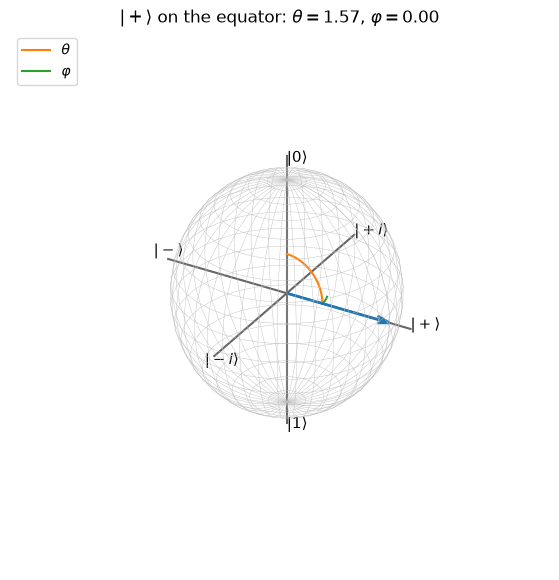

In [4]:
def draw_math_bloch(theta: float, phi: float, label: str) -> None:
    """Hand-drawn Bloch sphere: poles, equator, one state, theta/phi arcs."""
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    ax.plot_wireframe(
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones_like(u), np.cos(v)),
        color="0.75",
        linewidth=0.3,
    )

    ax.plot([-1.2, 1.2], [0, 0], [0, 0], color="0.4")
    ax.plot([0, 0], [-1.2, 1.2], [0, 0], color="0.4")
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], color="0.4")

    for (x, y, z), txt in {
        (0, 0, 1.15): r"$|0\rangle$",
        (0, 0, -1.25): r"$|1\rangle$",
        (1.2, 0, 0): r"$|+\rangle$",
        (-1.35, 0, 0): r"$|-\rangle$",
        (0, 1.2, 0): r"$|+i\rangle$",
        (0, -1.35, 0): r"$|-i\rangle$",
    }.items():
        ax.text(x, y, z, txt, fontsize=11)

    sx = np.sin(theta) * np.cos(phi)
    sy = np.sin(theta) * np.sin(phi)
    sz = np.cos(theta)
    ax.quiver(0, 0, 0, sx, sy, sz, color="C0", arrow_length_ratio=0.12, linewidth=2)

    t = np.linspace(0, theta, 40)
    ax.plot(
        0.35 * np.sin(t) * np.cos(phi),
        0.35 * np.sin(t) * np.sin(phi),
        0.35 * np.cos(t),
        color="C1",
        label=r"$\theta$",
    )
    p = np.linspace(0, phi if abs(phi) > 1e-12 else 0.35, 40)
    ax.plot(0.35 * np.cos(p), 0.35 * np.sin(p), np.zeros_like(p), color="C2", label=r"$\varphi$")

    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    ax.set_title(rf"{label}: $\theta={theta:.2f}$, $\varphi={phi:.2f}$")
    ax.legend(loc="upper left")
    plt.show()


th, ph = bloch_angles(*states["|+>"])
draw_math_bloch(th, ph, r"$|+\rangle$ on the equator")

## Pauli X is a quantum NOT

$X|0\rangle = |1\rangle$ and $X|1\rangle = |0\rangle$. The matrix is
$\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$.
On the Bloch sphere the arrow flips from north to south.

X on |0>
   ┌───┐
q: ┤ X ├
   └───┘
  +1.000+0.000j |1>

X on |0>


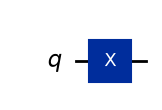

  +1.000+0.000j |1>



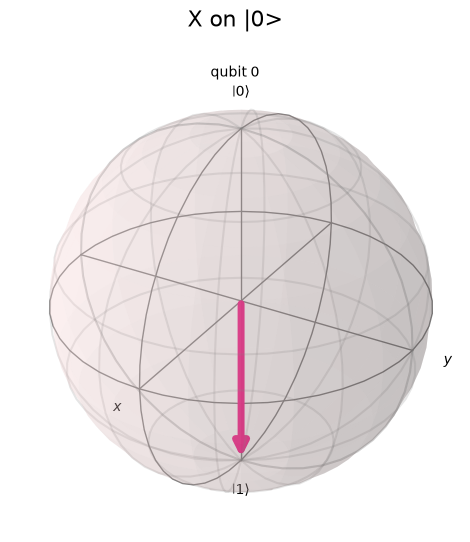

matrix:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


In [5]:
x_circ = qk.QuantumCircuit(1)
x_circ.x(0)
show(x_circ, "X on |0>")
show_mpl(x_circ, "X on |0>")
print("matrix:\n", qk.quantum_info.Operator(x_circ).data.round(3))

## Z and Y, and the phase gates S and T

- $Z$ flips the sign of $|1\rangle$ and leaves $|0\rangle$ alone.
  On the equator that is a $180^\circ$ yaw: $|+\rangle \mapsto |-\rangle$.
- $S = \sqrt{Z}$ and $T = \sqrt{S}$ are finer phase ticks around $z$.
- $Y = iXZ$ rotates around the $y$ axis ($|0\rangle$ goes to $i|1\rangle$).

H|0> = |+>
   ┌───┐
q: ┤ H ├
   └───┘
  +0.707+0.000j |0>
  +0.707+0.000j |1>

H|0> = |+>


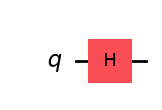

  +0.707+0.000j |0>
  +0.707+0.000j |1>



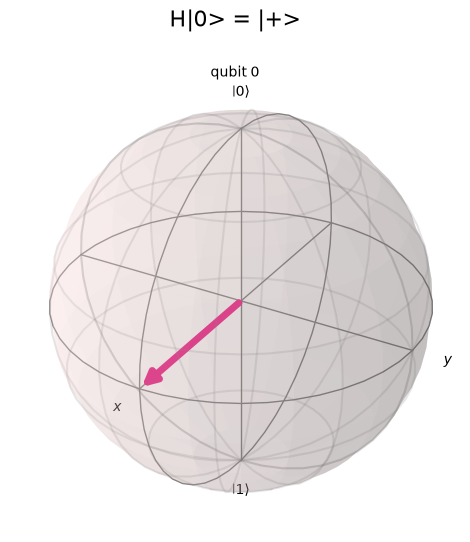

Z|+> = |->
   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘
  +0.707+0.000j |0>
  -0.707+0.000j |1>

Z|+> = |->


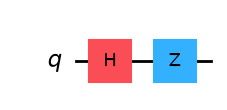

  +0.707+0.000j |0>
  -0.707+0.000j |1>



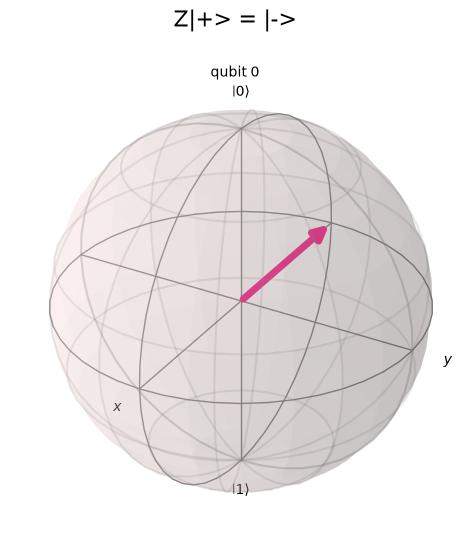

S|+>
   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘
  +0.707+0.000j |0>
  +0.000+0.707j |1>

S|+>


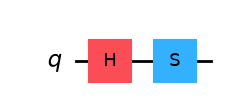

  +0.707+0.000j |0>
  +0.000+0.707j |1>



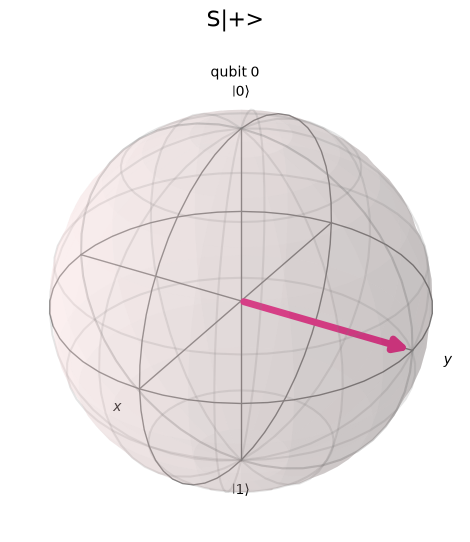

T|+>
   ┌───┐┌───┐
q: ┤ H ├┤ T ├
   └───┘└───┘
  +0.707+0.000j |0>
  +0.500+0.500j |1>

T|+>


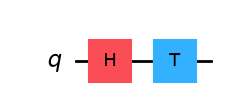

  +0.707+0.000j |0>
  +0.500+0.500j |1>



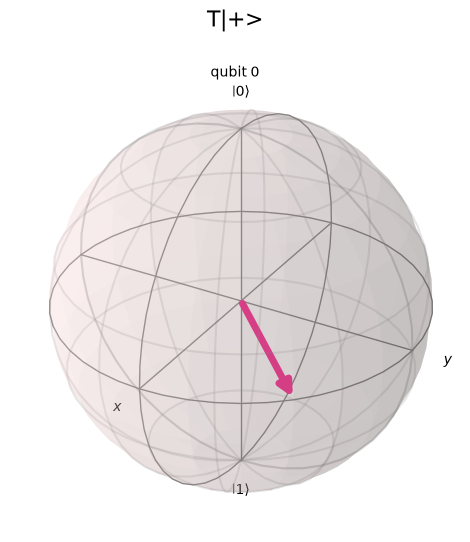

Y|0>
   ┌───┐
q: ┤ Y ├
   └───┘
  +0.000+1.000j |1>

Y|0>


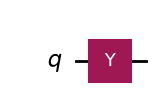

  +0.000+1.000j |1>



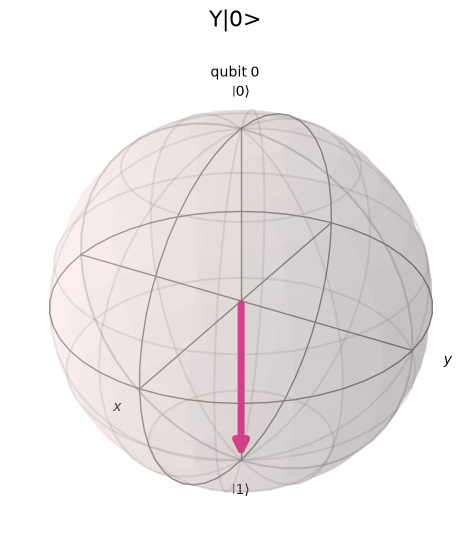

In [6]:
plus = qk.QuantumCircuit(1)
plus.h(0)
show(plus, "H|0> = |+>")
show_mpl(plus, "H|0> = |+>")

z_plus = qk.QuantumCircuit(1)
z_plus.h(0)
z_plus.z(0)
show(z_plus, "Z|+> = |->")
show_mpl(z_plus, "Z|+> = |->")

s_plus = qk.QuantumCircuit(1)
s_plus.h(0)
s_plus.s(0)
show(s_plus, "S|+>")
show_mpl(s_plus, "S|+>")

t_plus = qk.QuantumCircuit(1)
t_plus.h(0)
t_plus.t(0)
show(t_plus, "T|+>")
show_mpl(t_plus, "T|+>")

y_zero = qk.QuantumCircuit(1)
y_zero.y(0)
show(y_zero, "Y|0>")
show_mpl(y_zero, "Y|0>")

## Hadamard creates equal superposition

$H|0\rangle = (|0\rangle+|1\rangle)/\sqrt{2}$. The Bloch arrow sits on the
equator *before* the meter. Measuring many times gives a 50/50 histogram.

H|0> before measure
   ┌───┐
q: ┤ H ├
   └───┘
  +0.707+0.000j |0>
  +0.707+0.000j |1>

H|0> = |+> on the Bloch equator


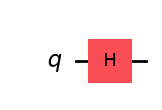

  +0.707+0.000j |0>
  +0.707+0.000j |1>



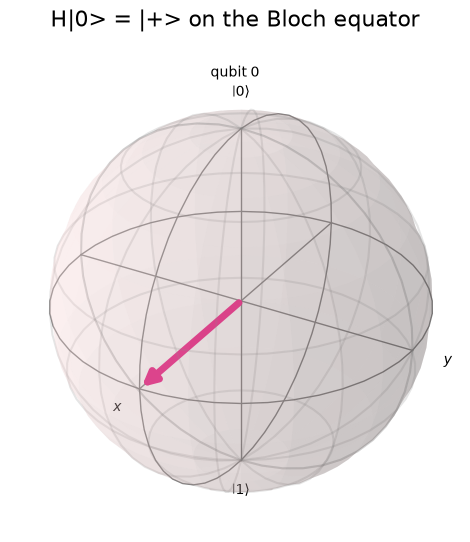

{'1': 1015, '0': 985}


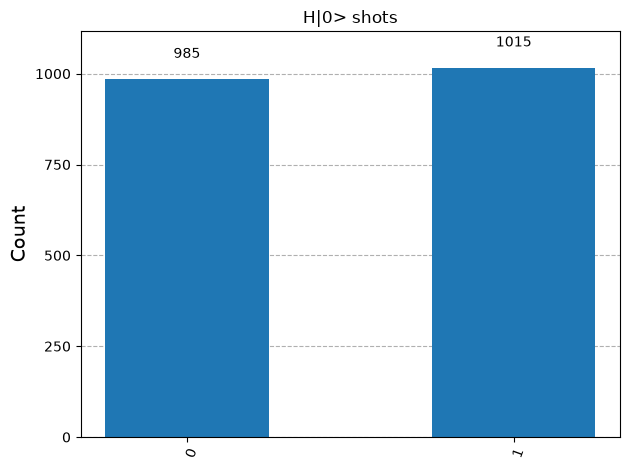

In [7]:
h_prep = qk.QuantumCircuit(1)
h_prep.h(0)
show(h_prep, "H|0> before measure")
show_mpl(h_prep, "H|0> = |+> on the Bloch equator")

h = qk.QuantumCircuit(1, 1)
h.h(0)
h.measure(0, 0)
sim = qka.AerSimulator()
counts = sim.run(qk.transpile(h, sim), shots=2000).result().get_counts()
print(counts)
display(qk.visualization.plot_histogram(counts, title="H|0> shots"))

## CX and SWAP

CX flips the target when the control is $|1\rangle$. SWAP exchanges two
qubits. Both are written out as a full computational-basis table so you
can see every input.

Every row below is a **product** state, so two Bloch arrows still make
sense. An entangled state would shrink both arrows toward the origin —
that picture belongs in the superposition notebook, not here.

In [ ]:
print("CX  control=q1  target=q0")
for c, t in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    qc = qk.QuantumCircuit(2)
    if t:
        qc.x(0)
    if c:
        qc.x(1)
    qc.cx(1, 0)
    out = next(iter(qk.quantum_info.Statevector.from_instruction(qc).to_dict()))
    print(f"  |{c}{t}> -> |{out}>")

cx_demo = qk.QuantumCircuit(2)
cx_demo.x(1)
cx_demo.cx(1, 0)
show(cx_demo, "CX |10> -> |11>")
show_mpl(cx_demo, "CX |10> -> |11> (still a product state)")

print("\nSWAP |10> -> |01>")
sw = qk.QuantumCircuit(2)
sw.x(1)
sw.swap(0, 1)
show(sw, "after SWAP")
show_mpl(sw, "SWAP |10> -> |01>")